In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import ttest_ind_from_stats

In [3]:
variants_in_top = ['WT',
                   'Q528M',
                   'V658Y',
                   'H534Y',
                   'L731E',
                   'F468I',]

tm_ = {'WT':0,
                'Q528M':-0.12,
                'V658Y':1.45,
                'H534Y':-0.21,
                "L731E":0.29,
                "F468I":2.96}

tm_std_ = {'WT':0.18,
                    'Q528M':0.166,
                    'V658Y':0.838,
                    'H534Y':0.058,
                    'L731E':0.38,
                    'F468I':0.2}

resact_ = {'WT':23.376623,
                    'Q528M':16.66667,
                    'V658Y':2.953586,
                    'H534Y':26.77165,
                    'L731E':21.052632,
                    'F468I':60.144928}

resact_std_ = {'WT':11.05745,
                        'Q528M':4.3,
                        'V658Y':4.3,
                        'H534Y':14.1,
                        'L731E':12.611574,
                        'F468I':19.495354}

In [ ]:
exp_top = pd.DataFrame(variants_in_top, columns=['mutant'])
exp_top['ResAct'] = exp_top['mutant'].map(resact_)
exp_top['ResAct_std'] = exp_top['mutant'].map(resact_std_)
exp_top['dTm'] = exp_top['mutant'].map(tm_)
exp_top['Tm_std'] = exp_top['mutant'].map(tm_std_)

In [7]:
exp_top

,mutant,ResAct,ResAct_std,dTm,Tm_std
0,WT,23.376623,11.057450,0.00,0.180
1,Q528M,16.666670,4.300000,-0.12,0.166
2,V658Y,2.953586,4.300000,1.45,0.838
3,H534Y,26.771650,14.100000,-0.21,0.058
4,L731E,21.052632,12.611574,0.29,0.380
5,F468I,60.144928,19.495354,2.96,0.200


In [9]:
results = []
sig_threshold1 = 0.05
sig_threshold2 = 0.01

# Get WT replicates from the first row
wt_dTm = exp_top['dTm'].iloc[0]
wt_dTm_std = exp_top['Tm_std'].iloc[0]


# Loop over mutants (skip the first row which is WT)
for mut in variants_in_top[1:]:
    dTm_ = exp_top[exp_top.mutant==mut].dTm.values[0]
    dTm_std_ = exp_top[exp_top.mutant==mut].Tm_std.values[0]

    # Welch's t-test (unequal variances by default with equal_var=False)
    t_stat, p_val_two_sided = ttest_ind_from_stats(dTm_, dTm_std_, 3, wt_dTm, wt_dTm_std, 3, equal_var=False)

    # Convert to one-sided test for (mutant > WT)
    if np.isnan(t_stat):
        p_one_sided = np.nan
    elif t_stat > 0:
        p_one_sided = p_val_two_sided / 2.0
    else:
        p_one_sided = 1.0

    significant1 = (p_one_sided < sig_threshold1) if np.isfinite(p_one_sided) else False
    significant2 = (p_one_sided < sig_threshold2) if np.isfinite(p_one_sided) else False

    results.append({
        "Mutant": mut,
        "t_stat": t_stat,
        "p_val_one_sided": p_one_sided,
        "Significant1": significant1,
        "Significant2": significant2
    })

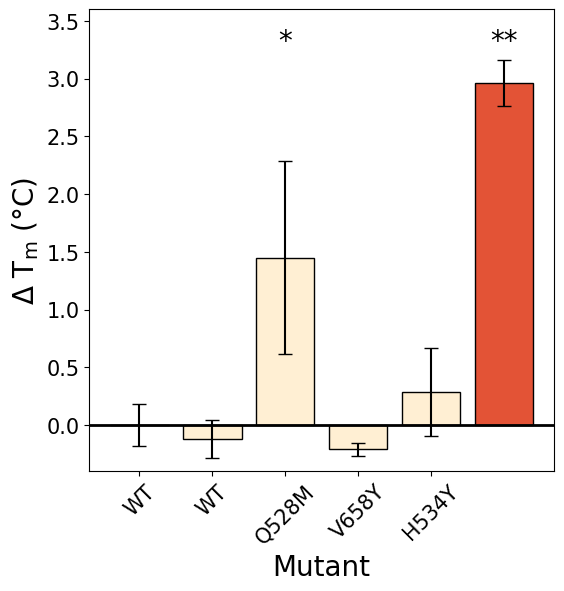

In [13]:
width = 0.8  # the width of the bars
fig, ax = plt.subplots(figsize=(6, 6))

ax.bar(exp_top['mutant'].iloc[0], exp_top['dTm'].iloc[0], yerr=exp_top['Tm_std'].iloc[0], capsize=5,
       width=width, color='lightgray', edgecolor='black')

# Loop over mutants (skip the first row which is WT)
for imut, mut in enumerate(variants_in_top[1:]):
    dTm_ = exp_top[exp_top.mutant==mut].dTm.values[0]
    dTm_std_ = exp_top[exp_top.mutant==mut].Tm_std.values[0]

    if imut < 4:
        c_ = '#FFEFD3'
    else:
        c_ = '#E35336'

    ax.bar(mut, dTm_, yerr=dTm_std_, capsize=5,
              width=width, color=c_, edgecolor='black')
    

for i, res in enumerate(results):
    i += 1
    if res['Significant2']:
        ax.text(i, 3.2, '**', 
                ha='center', va='bottom', color='k', fontsize=20)
    elif res['Significant1']:
        ax.text(i, 3.2, '*', 
                ha='center', va='bottom', color='k', fontsize=20)


ax.axhline(0, color='black', linewidth=2, linestyle='-')
ax.set_xticks(range(len(variants_in_top[:-2])+1))

ax.set_ylim(-0.4, 3.6)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xticklabels(['WT'] + variants_in_top[:-2], rotation=45, ha='center', fontsize=15)
ax.set_xlabel('Mutant', fontsize=20)
ax.set_ylabel(r'$\Delta$ T$_\mathrm{m}$ (°C)', fontsize=20)
plt.show()

In [14]:

results = []
sig_threshold = 0.05

# Get WT replicates from the first row
wt_resact = exp_top['ResAct'].iloc[0]
wt_resact_std = exp_top['ResAct_std'].iloc[0]

# Loop over mutants (skip the first row which is WT)
# Loop over mutants (skip the first row which is WT)
for mut in variants_in_top[1:]:
    resact_ = exp_top[exp_top.mutant==mut].ResAct.values[0]
    resact_std_ = exp_top[exp_top.mutant==mut].ResAct_std.values[0]

    # Welch's t-test (unequal variances by default with equal_var=False)
    t_stat, p_val_two_sided = ttest_ind_from_stats(resact_, resact_std_, 3, wt_resact, wt_resact_std, 3, equal_var=False)

    # Convert to one-sided test for (mutant > WT)
    if np.isnan(t_stat):
        p_one_sided = np.nan
    elif t_stat > 0:
        p_one_sided = p_val_two_sided / 2.0
    else:
        p_one_sided = 1.0

    significant = (p_one_sided < sig_threshold) if np.isfinite(p_one_sided) else False

    results.append({
        "Mutant": mut,
        "t_stat": t_stat,
        "p_val_one_sided": p_one_sided,
        "Significant": significant,
    })

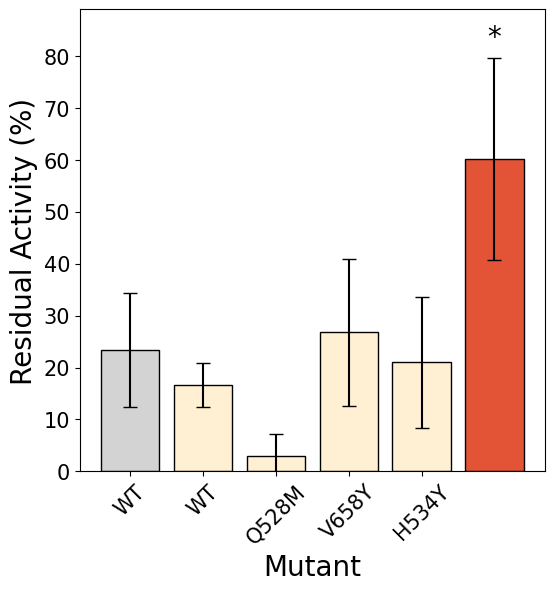

In [15]:
width = 0.8  # the width of the bars
fig, ax = plt.subplots(figsize=(6, 6))

ax.bar(exp_top['mutant'].iloc[0], exp_top['ResAct'].iloc[0], yerr=exp_top['ResAct_std'].iloc[0], capsize=5,
       width=width, color='lightgray', edgecolor='black')

# Loop over mutants (skip the first row which is WT)
for imut, mut in enumerate(variants_in_top[1:]):
    resact_ = exp_top[exp_top.mutant==mut].ResAct.values[0]
    resact_std_ = exp_top[exp_top.mutant==mut].ResAct_std.values[0]

    if imut < 4:
        c_ = '#FFEFD3'
    else:
        c_ = '#E35336'
    ax.bar(mut, resact_, yerr=resact_std_, capsize=5,
              width=width, color=c_, edgecolor='black')
    

for i, res in enumerate(results):
    i += 1
    if res['Significant']:
        ax.text(i, 81, '*', 
                ha='center', va='bottom', color='k', fontsize=20)


ax.set_xticks(range(len(variants_in_top[:-2])+1))

ax.set_ylim([0, 89])

ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xticklabels(['WT'] + variants_in_top[:-2], rotation=45, ha='center', fontsize=15)
ax.set_xlabel('Mutant', fontsize=20)
ax.set_ylabel('Residual Activity (%)', fontsize=20)
plt.show()